# Overview of the Data

#### Attributs du dataset :
- `Administrative`:Volume de pages administratives. Compte le nombre de pages (ex: compte client, FAQ, mentions légales).
  Une valeur élevée peut    indiquer un besoin de gérer un compte avant achat, ou à l'inverse, une friction avant abandon.
- `Administrative_Duration`: Temps total (secondes) passé sur les pages administratives. Combiné à Administrative, cela permet de calculer un temps
  moyen par page pour détecter des difficultés de navigation.
- `Informational`: Volume de pages informatives. Nombre de pages "À propos", guides ou blogs consultés. Souvent signe d'une phase de découverte ou
  de recherche pré-achat.
- `Informational_Duration`:Temps total passé sur les pages informatives. Un temps long sur peu de pages indique une lecture attentive (prospect
  qualifié).
- `ProductRelated`: Volume de fiches produits consultées. C'est un indicateur clé d'intention d'achat. Plus ce nombre est élevé, plus l'utilisateur
  compare ou hésite.
- `ProductRelated_Duration`: Temps total passé sur les fiches produits. Crucial pour distinguer un "zapping" rapide d'une analyse détaillée du produit.
- `BounceRates`: Taux de rebond moyen des pages vues durant la session.
- Une valeur proche de 0.0 signifie que l'utilisateur a interagi
  Une valeur proche de 1.00 (100%) signifie que l'utilisateur est partie directement
  Très corrélé négativement avec Revenue.
- `ExitRates`: Taux de sortie moyen. Pourcentage de fois où une page donnée était la dernière de la session.
  une page peut avoir un fort taux de sortie même si la navigation a été longue (ex: page de confirmation de commande).
- `PageValues`: Une page a une valeur > 0 si sa visite a précédé ou contribué à une transaction. C'est la feature la plus puissante pour prédire
  Revenue.
- `SpecialDay`: Proximité d'une fête commerciale. Valeur normalisée entre 0.0 (loin) et 1.0
- `Month` : Mois de la visite
- `Weekend` :Indique si la visite a eu lieu le week-end.
- `OperatingSystems` : Système d'exploitation du visiteur 
- `Browser :`Navigateur utilisé. À analyser en lien avec les BounceRates (certains vieux navigateurs causent des bugs et donc des abandons).
- `Region` : Zone géographique. Feature essentielle pour la segmentation marketing et la logistique.
- `TrafficType` : Source du trafic (ex: 1 = Direct, 2 = Réseaux Sociaux, 3 = Moteur de recherche). Critique pour calculer le ROI marketing
- `VisitorType`Type de visiteur : Returning_Visitor (Client connu) vs New_Visitor.
  Une des features les plus discriminantes : un visiteur récurrent a historiquement un taux de conversion (Revenue) bien supérieur.
- `Revenue` : Label de Classification. True si la session s'est terminée par une transaction, False sinon. Le dataset étant fortement déséquilibré (peu
  de True), des métriques comme la Precision, Recall et F1-Score seront privilégiées par rapport à la simple Accuracy.


# PART 1 :DATA PREPARATION 

## 1. Préparation de l'environnement technique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librairies importées avec succès !")

Librairies importées avec succès !


## 2. Import du dataset 

In [2]:
df=pd.read_csv("online_shoppers_intention.csv")
print("dataset importer avec succée")

dataset importer avec succée


## 3.Vérifier que les données sont de type DataFrame

In [3]:
type(df)

pandas.core.frame.DataFrame

## 4. Afficher les dimensions du DataFrame

In [4]:
df.shape
# (nombre de lignes, nombre de colonnes)

(12330, 18)

## 5. Afficher les 5 premières lignes du dataset

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 6. Afficher le nom et l'index de chaque colonne

In [6]:
print("\nIndex et nom de chaque colonne :")
for index ,columns in enumerate (df):
    print (index , columns )


Index et nom de chaque colonne :
0 Administrative
1 Administrative_Duration
2 Informational
3 Informational_Duration
4 ProductRelated
5 ProductRelated_Duration
6 BounceRates
7 ExitRates
8 PageValues
9 SpecialDay
10 Month
11 OperatingSystems
12 Browser
13 Region
14 TrafficType
15 VisitorType
16 Weekend
17 Revenue


## 7. Vérifier le types de variables de chaque colonne 

In [7]:
print(df.dtypes)
print("""\nLe dataset contient :
- des variables numériques (ex: bounceRates, ExitRates , Pagevalues )
- des variables catégorielles (ex: Month, VisitorType)
- des variables booleen (ex:weekend , Revenue)
""")

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Le dataset contient :
- des variables numériques (ex: bounceRates, ExitRates , Pagevalues )
- des variables catégorielles (ex: Month, VisitorType)
- des variables booleen (ex:weekend , Revenue)



### 8.Corriger type de la colonne total charges 

In [8]:
#pas de probleme de type a corriger

### 9.Description des variables

In [9]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [10]:
df.describe(include=['object', 'bool'])

,Month,VisitorType,Weekend,Revenue
count,12330,12330,12330,12330
unique,10,3,2,2
top,May,Returning_Visitor,False,False
freq,3364,10551,9462,10422


## 10. Afficher toutes les informations sur le dataset

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

### 11. Le dataset contient-il des valeurs manquantes ? 

In [12]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### 12. Supprimer les lignes vides

In [13]:
# pas de valeur manquantes

### 13.suppriemr les incoherences entre les donnees 

In [14]:
# Remove rows with page count = 0 but positive duration
inconsistent_mask = (
    ((df['Administrative'] == 0) & (df['Administrative_Duration'] > 0)) |
    ((df['Informational'] == 0) & (df['Informational_Duration'] > 0)) |
    ((df['ProductRelated'] == 0) & (df['ProductRelated_Duration'] > 0))
)
print(f"Removing {inconsistent_mask.sum()} inconsistent rows.")
df = df[~inconsistent_mask].reset_index(drop=True)

Removing 0 inconsistent rows.


## Visualisation des donneés

### 1-Distribution du Revenue (variable cible)

In [15]:
df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

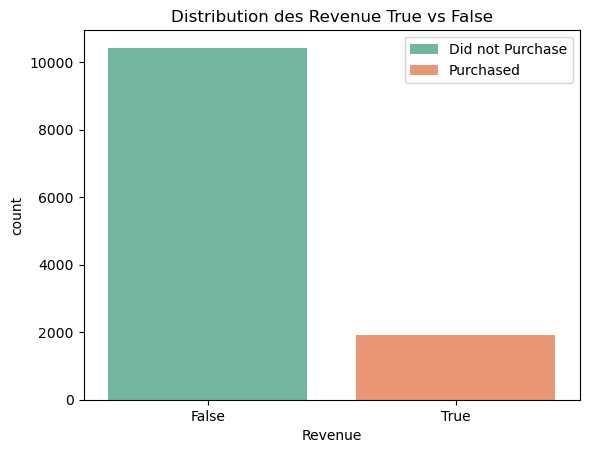

La distribution montre le nombre de clients qui achéte et ceux qui n'achete pas.
les classes sont déséquilibrées(peu de True), cela peut impacter les performances du modèle.
Dans ce cas , des métriques comme la Precision, Recall et F1-Score seront privilégiées par rapport à la simple Accuracy.


In [16]:
sns.countplot(x='Revenue', hue ='Revenue',data=df, palette="Set2")
plt.title("Distribution des Revenue True vs False")
plt.legend(labels=['Did not Purchase','Purchased'])
plt.show()
print("""La distribution montre le nombre de clients qui achéte et ceux qui n'achete pas.
les classes sont déséquilibrées(peu de True), cela peut impacter les performances du modèle.
Dans ce cas , des métriques comme la Precision, Recall et F1-Score seront privilégiées par rapport à la simple Accuracy.""")

### 2 - Proportion des Revenue 

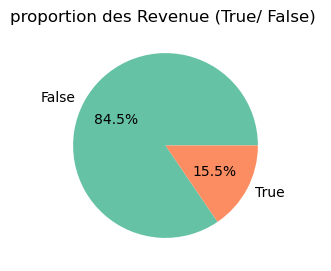

In [17]:
plt.figure(figsize=(3,3))
freq_churn = df["Revenue"].value_counts(normalize=True)
plt.pie(
    freq_churn,
    labels=freq_churn.index, #noms des catégories
    autopct='%1.1f%%', # afficher le pourcentage dans le pie chart  
    colors=sns.color_palette("Set2"),  # palette Seaborn
)
plt.title("proportion des Revenue (True/ False) ")
plt.show()

### 3 - Proportion des visiteur au weekend

In [18]:
df['Weekend'].value_counts()

Weekend
False    9462
True     2868
Name: count, dtype: int64

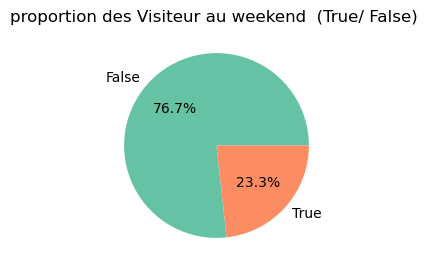

Interpretation :23% des visiteurs visite le site au weekend 


In [19]:
plt.figure(figsize=(3,3))
freq_churn = df["Weekend"].value_counts(normalize=True)
plt.pie(
    freq_churn,
    labels=freq_churn.index, #noms des catégories
    autopct='%1.1f%%', # afficher le pourcentage dans le pie chart  
    colors=sns.color_palette("Set2"),  # palette Seaborn
)
plt.title("proportion des Visiteur au weekend  (True/ False) ")
plt.show()
print("""Interpretation :23% des visiteurs visite le site au weekend """)

### 4-Types de Visiteur (VisitorType)

In [20]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

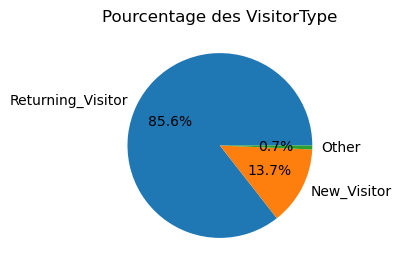

Interpretation : 
les VisitorType les plus dominant sont les Returning-Visitor


In [21]:
plt.figure(figsize=(3,3))
freq_contract=df["VisitorType"].value_counts(normalize=True)
plt.pie(
    freq_contract,
    labels=freq_contract.index,
    autopct='%1.1f%%',
)
plt.title("Pourcentage des VisitorType")
plt.show()
print("""Interpretation : 
les VisitorType les plus dominant sont les Returning-Visitor""" )

### 4.1 — Proportion des VisitorType

### Revenue vs Visitor type (Relation)

In [22]:
Revenue_visitorType=df.groupby('VisitorType')['Revenue'].value_counts(normalize=True).unstack() * 100
print(Revenue_visitorType)

Revenue                False      True 
VisitorType                            
New_Visitor        75.088548  24.911452
Other              81.176471  18.823529
Returning_Visitor  86.067671  13.932329


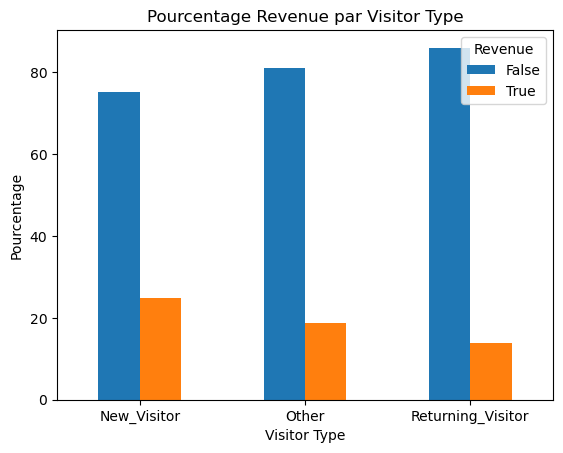

In [23]:
Revenue_visitorType.plot(kind="bar")

plt.title("Pourcentage Revenue par Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Pourcentage")
plt.legend(title="Revenue")
plt.xticks(rotation=0)
plt.show()

### Revenue by Month

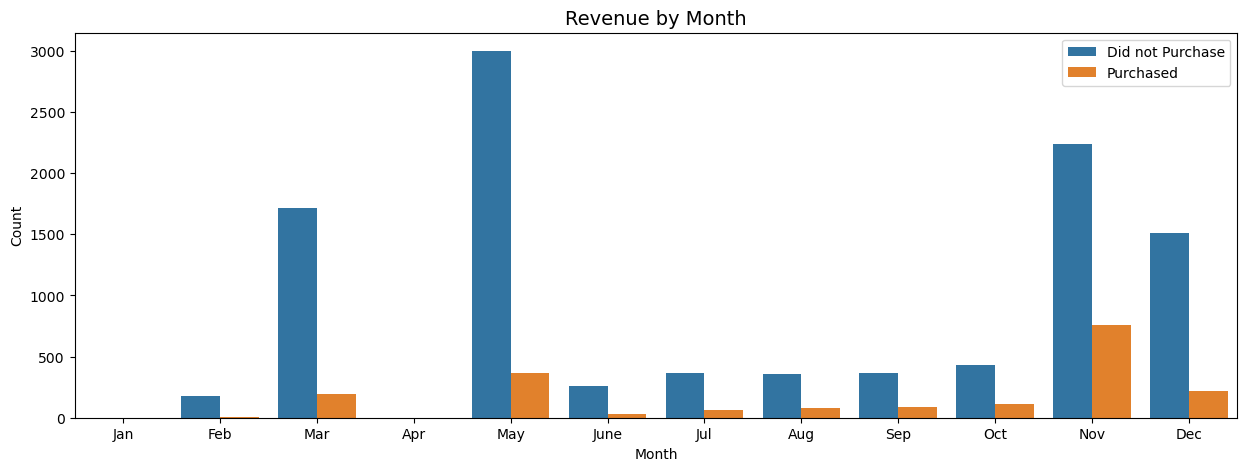

 In January and April, there were no website visits recorded.
A lot of transactions happen towards the end of the year, with November and December recording the highest and third-highest Revenue generated. Although, these months do not have the highest website visits recorded.
The top four (4) months with the most visits are May, November, March and December.


In [24]:
plt.figure(figsize=(15,5))
plt.title("Revenue by Month", fontsize=14)

orderlist = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']

sns.countplot(x='Month', data=df, hue = 'Revenue', order=orderlist)
plt.legend(labels=['Did not Purchase','Purchased'])
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks()
plt.yticks()
plt.show()
print (""" In January and April, there were no website visits recorded.
A lot of transactions happen towards the end of the year, with November and December recording the highest and third-highest Revenue generated. Although, these months do not have the highest website visits recorded.
The top four (4) months with the most visits are May, November, March and December.""")

### 5.1 — visualisation de  la variable TrafficType 

Text(0, 0.5, 'total ')

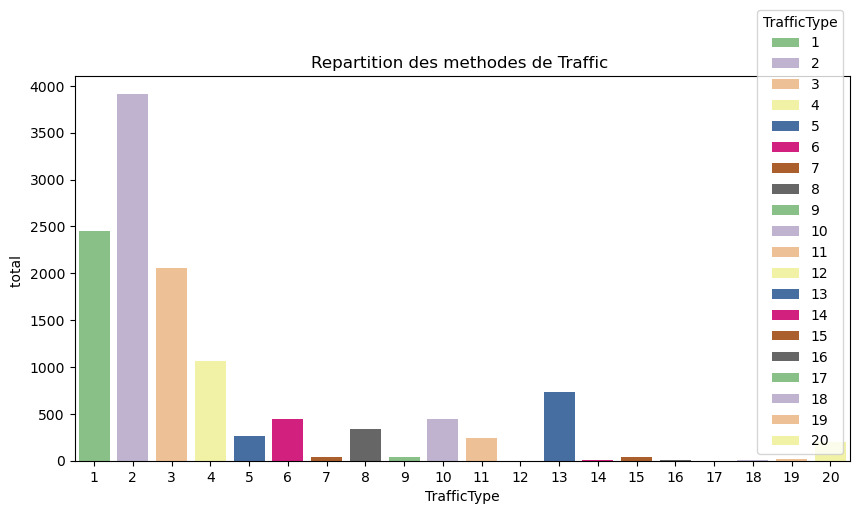

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="TrafficType", hue ="TrafficType", palette="Accent")
plt.title("Repartition des methodes de Traffic ")
plt.ylabel("total ")

### 8.Matrice de corrélation  des variables categorielle 

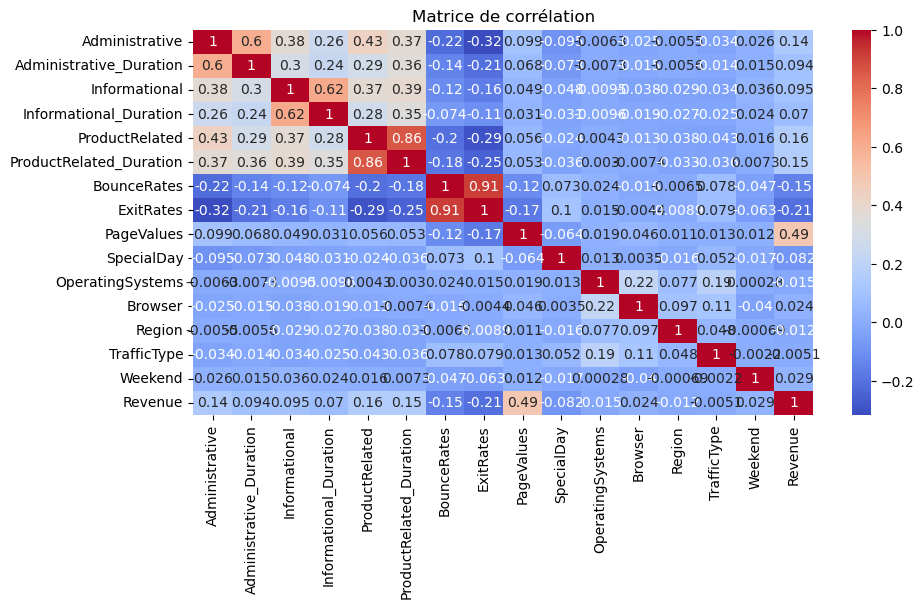

 interpretation :
High correlation between:
  - BounceRates & ExitRates (0.9). 
  - ProductRelated & ProductRelated_Duration (0.85).

Moderate Correlations:

  - Administrative & Administrative DUration (0.6)
  - Informational and Informational Duration (0.62)
  
Revenue(target) :
  - Moderate Correlation with PageValues (0.42) 


In [29]:
plt.figure(figsize=(10,5))
sns.heatmap(df.select_dtypes(include=['int64','float64',"bool"]).corr(),
            annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()
print(""" interpretation :
High correlation between:
  - BounceRates & ExitRates (0.9). 
  - ProductRelated & ProductRelated_Duration (0.85).

Moderate Correlations:

  - Administrative & Administrative DUration (0.6)
  - Informational and Informational Duration (0.62)
  
Revenue(target) :
  - Moderate Correlation with PageValues (0.42) """)

### Boxplot PageValues vs Revenue

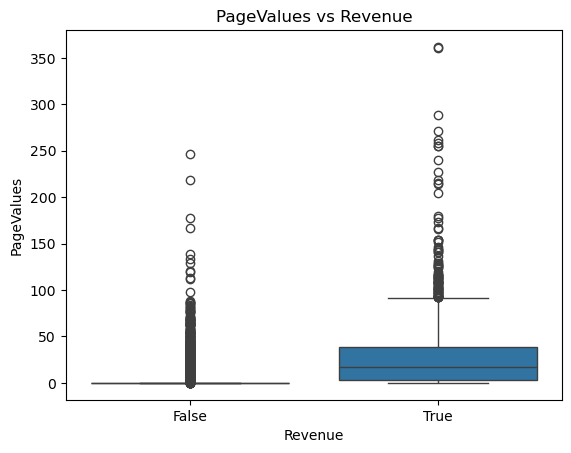

Interpretation 1 :
Le boxplot met en évidence une séparation nette entre les visiteurs ayant effectué un achat (True) et ceux n’ayant pas converti (False).
Les utilisateurs sans achat présentent majoritairement des valeurs de PageValues proches de zéro, tandis que les acheteurs affichent des 
valeurs significativement plus élevées et plus dispersées. 

Cette différence marquée suggère une forte association entre l’exposition à des pages à forte valeur et la probabilité de conversion,
confirmant ainsi que PageValues constitue un indicateur pertinent de l’intention d’achat et un excellent prédicteur du comportement de conversion..


In [37]:
sns.boxplot(x='Revenue', y='PageValues', data=df,) 
plt.title("PageValues vs Revenue")
plt.show()
print("""Interpretation 1 :
Le boxplot met en évidence une séparation nette entre les visiteurs ayant effectué un achat (True) et ceux n’ayant pas converti (False).
Les utilisateurs sans achat présentent majoritairement des valeurs de PageValues proches de zéro, tandis que les acheteurs affichent des 
valeurs significativement plus élevées et plus dispersées. 

Cette différence marquée suggère une forte association entre l’exposition à des pages à forte valeur et la probabilité de conversion,
confirmant ainsi que PageValues constitue un indicateur pertinent de l’intention d’achat et un excellent prédicteur du comportement de conversion..""")

### Page Metrics Analysis

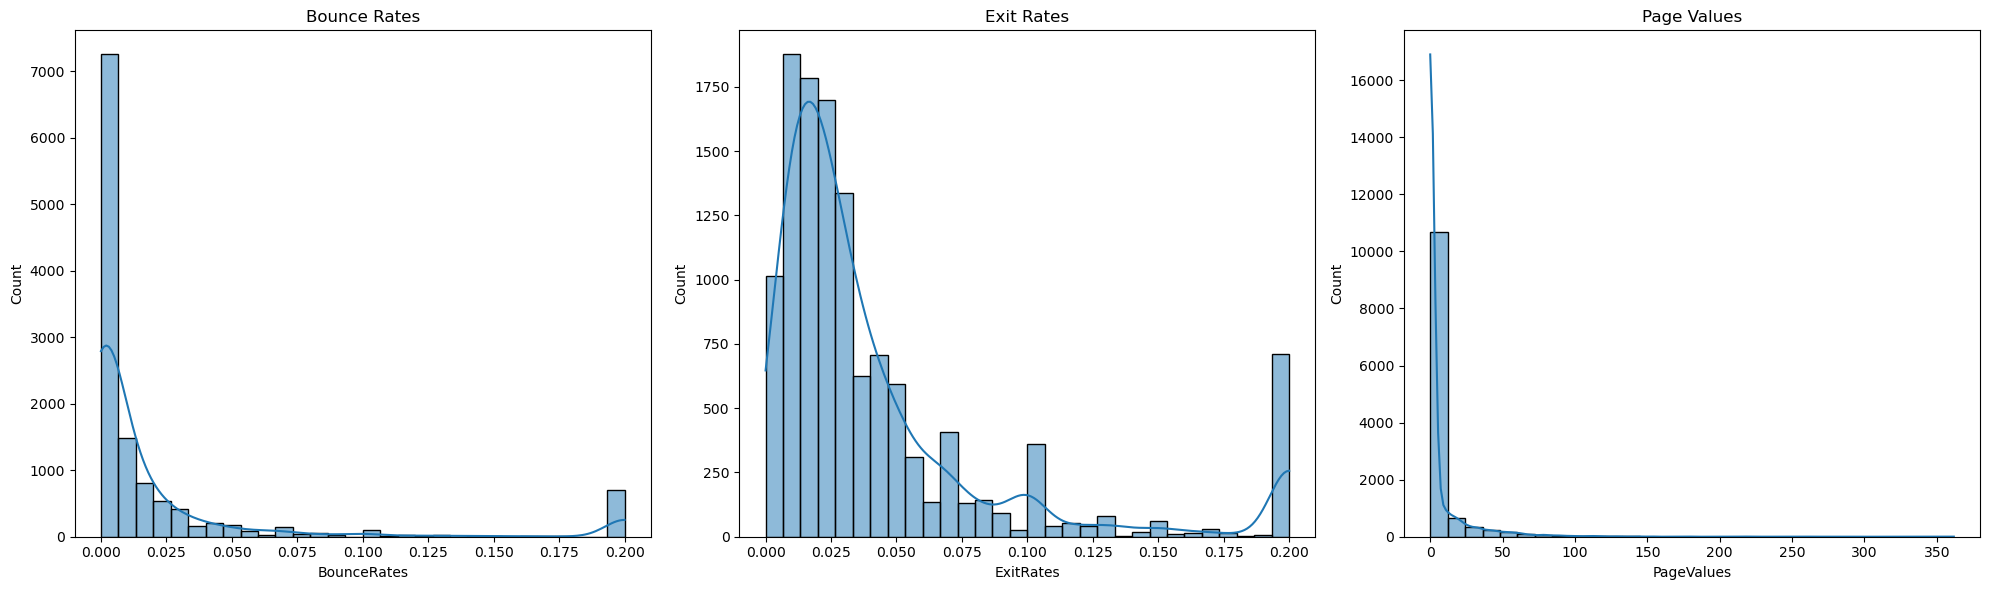

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(df['BounceRates'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Bounce Rates')


sns.histplot(df['ExitRates'], ax=axes[1], kde=True, bins=30)
axes[1].set_title('Exit Rates')


sns.histplot(df['PageValues'], ax=axes[2], kde=True,bins=30)
axes[2].set_title('Page Values')


plt.tight_layout()
plt.show()

### interpretation pour plus comprendre les Termes
- BounceRates faible → le visiteur et entrain d interagir
- ExitRates faible → les utilisateurs continuent leur navigation
- ExitRates élevé → beaucoup de gens quittent le site depuis cette page
- PageValues élevé → pages avec forte valeur commerciale → potentiel d’achat élevé

### Revenue et Special day 

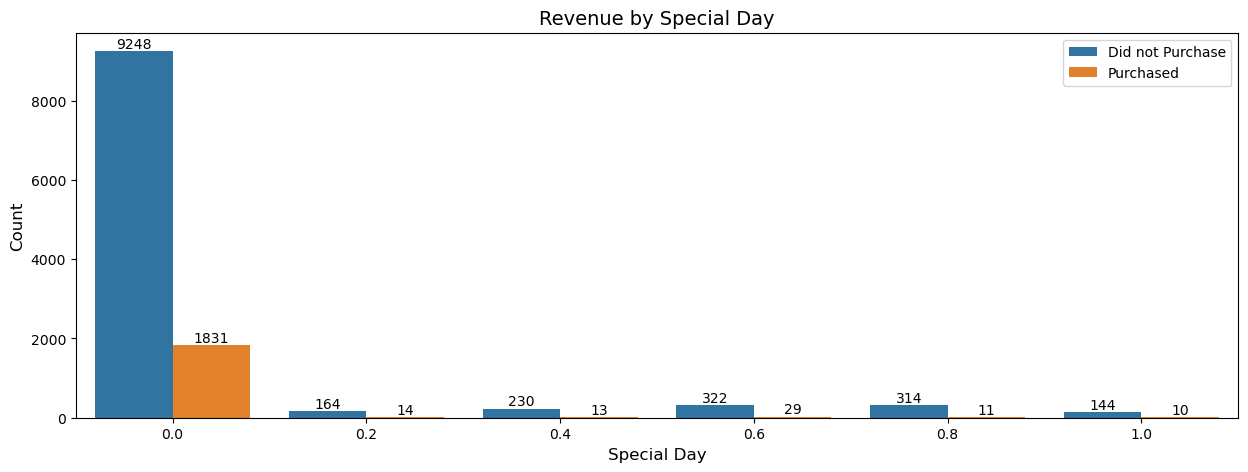

In [52]:
plt.figure(figsize=(15,5))
plt.title("Revenue by Special Day", fontsize=14)

ax = sns.countplot(x='SpecialDay', data=df, hue = 'Revenue')
ax.legend(labels=['Did not Purchase','Purchased'])
for i in ax.containers:
    ax.bar_label(i)
plt.xlabel("Special Day", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Part 2 :  Data Preparation

### 1.Encodage de la variable cible Revenue et weekend (variable booleen)

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
le = LabelEncoder()  # créer l'objet

In [55]:
print(df['Revenue'].unique())

[False  True]


In [56]:
df["Revenue"] = le.fit_transform(df["Revenue"])
df["Weekend"] = le.fit_transform(df["Weekend"])

In [57]:
print(df.Revenue.value_counts())
print(df.Weekend.value_counts())

Revenue
0    10422
1     1908
Name: count, dtype: int64
Weekend
0    9462
1    2868
Name: count, dtype: int64


### 2.Encodage des variables catégorielles (Month / VisitorType)

In [58]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = df.select_dtypes(include='object').columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
encoded_df.head()

,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [59]:
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [60]:
df.drop(["Month", "VisitorType"], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

### 3.Train and Split 

In [61]:
y = df['Revenue']
X = df.drop('Revenue', axis=1)

In [62]:
#Split Dataset into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

### Mettre tous les variables numerique sur la meme echelle

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 🔹 garder les colonnes
cols = X_train.columns

# 🔹 scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 remettre en DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=cols, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=cols, index=X_test.index)

In [64]:
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
6817,0.503521,1.071471,0.406323,0.863542,0.346926,-0.155872,-0.457806,-0.830885,-0.315934,-0.308439,...,-0.191395,-0.155589,-0.428705,-0.610600,-0.571151,-0.213717,-0.195904,2.553095,-0.086432,-2.474124
4398,4.116813,4.019989,-0.396555,-0.244141,0.460734,1.364110,-0.298033,-0.511144,-0.315934,-0.308439,...,-0.191395,-0.155589,-0.428705,1.637732,-0.571151,-0.213717,-0.195904,-0.391682,-0.086432,0.404184
10957,-0.700910,-0.466245,-0.396555,-0.244141,-0.495249,-0.435429,-0.457806,-0.144893,-0.315934,-0.308439,...,-0.191395,-0.155589,-0.428705,-0.610600,-0.571151,-0.213717,-0.195904,-0.391682,-0.086432,0.404184
11918,-0.700910,-0.466245,-0.396555,-0.244141,-0.700102,-0.668441,3.641178,3.201896,-0.315934,-0.308439,...,-0.191395,-0.155589,-0.428705,-0.610600,1.750849,-0.213717,-0.195904,2.553095,-0.086432,-2.474124
5535,2.310167,0.488909,-0.396555,-0.244141,0.119311,0.210352,-0.352703,-0.674751,-0.315934,-0.308439,...,-0.191395,-0.155589,-0.428705,-0.610600,-0.571151,-0.213717,5.104550,-0.391682,-0.086432,0.404184


### Modeling 

In [65]:
## Train and evaluate models. Predictive models that will be used are 
##Logistic Regression, KNeighbors Classifier, SVM, Decision Tree and Random Forest Classifier and  bagging DT 

### 1.LogisticRegression

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
LR = LogisticRegression()
LR = LR.fit(X_train, y_train) 
#The model looks at X_train (features)
#It compares them with y_train (target/output)
#It learns the relationship between them and give it a probability that help him to classify 

In [68]:
LR_pred = LR.predict(X_test)  #predire  y en la testant avec x  test 

### confusion_matrix , classification_report (LogisticRegression)

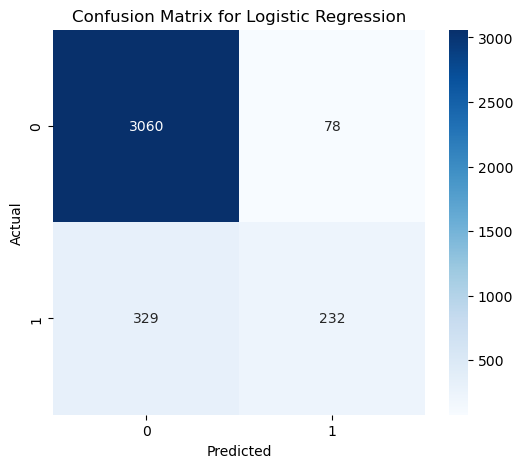

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3138
           1       0.75      0.41      0.53       561

    accuracy                           0.89      3699
   macro avg       0.83      0.69      0.74      3699
weighted avg       0.88      0.89      0.88      3699



In [69]:
from sklearn.metrics import confusion_matrix , classification_report
cm = confusion_matrix(y_test, LR_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, LR_pred))

### 2.KNN 

### Manual KNN 

In [70]:
from sklearn.neighbors import KNeighborsClassifier
KN = KNeighborsClassifier(n_neighbors=5)
KN = KN.fit(X_train, y_train)

In [71]:
y_predict = KN.predict(X_test)  #predire  y en la testant avec x test 

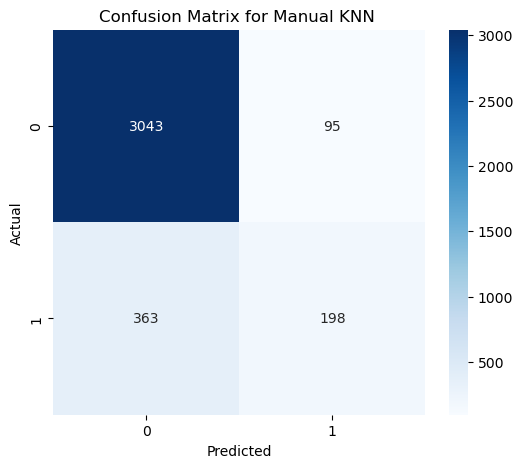

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3138
           1       0.68      0.35      0.46       561

    accuracy                           0.88      3699
   macro avg       0.78      0.66      0.70      3699
weighted avg       0.86      0.88      0.86      3699



In [72]:
cm = confusion_matrix(y_test,y_predict)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix for Manual KNN ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_predict))

### Automatic KNN 

In [79]:
from sklearn.model_selection import GridSearchCV
parameters = {
    'n_neighbors': list(range(1,15)),
    'metric': ['euclidean', 'manhattan']  # Exemple de métriques à tester
}
model = KNeighborsClassifier()
clf = GridSearchCV(model, parameters, scoring='recall', cv=5)
grille = clf.fit(X_train, y_train)
print(grille.best_params_)
print(grille.best_score_)

{'metric': 'euclidean', 'n_neighbors': 1}
0.4246922759190417


In [82]:
### the trainnig based on the automatic KNN 
Best_KNN = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
Best_KNN.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [83]:
knn_pred = Best_KNN.predict(X_test)

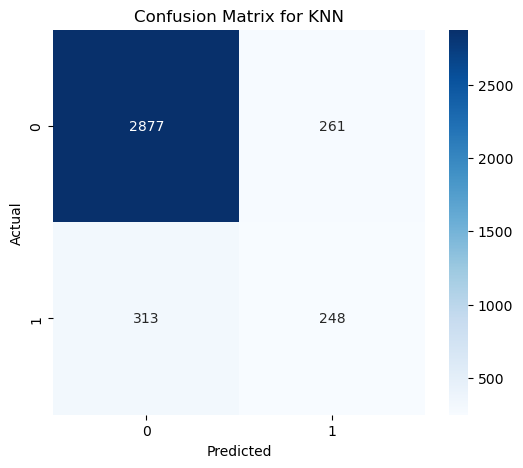

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      3138
           1       0.49      0.44      0.46       561

    accuracy                           0.84      3699
   macro avg       0.69      0.68      0.69      3699
weighted avg       0.84      0.84      0.84      3699



In [84]:
cm = confusion_matrix(y_test,knn_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix for KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test,knn_pred))

### SVC Model 

In [85]:
from sklearn.svm import SVC

svc_model = SVC()
svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

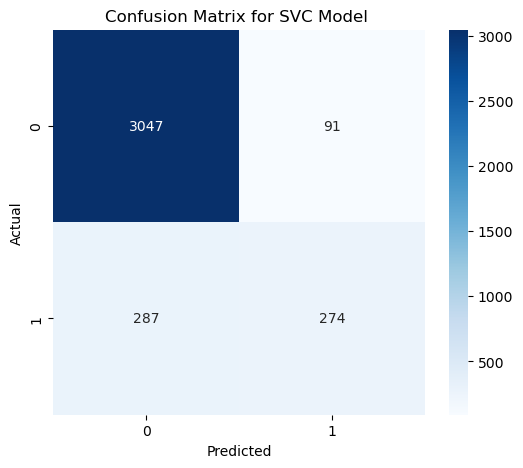

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3138
           1       0.75      0.49      0.59       561

    accuracy                           0.90      3699
   macro avg       0.83      0.73      0.77      3699
weighted avg       0.89      0.90      0.89      3699



In [86]:
cm = confusion_matrix(y_test,svc_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix for SVC Model ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test,svc_pred))

###  Modèle SVM avec noyau RBF

In [87]:
# Modèle SVM avec noyau RBF
SVC_RBF = SVC()

# Grille d'hyperparamètres
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf']
}
# GridSearch
grid = GridSearchCV(SVC_RBF, param_grid, cv=5, scoring='recall')

# Entraînement
grid.fit(X_train, y_train)

# Meilleurs paramètres
print("meilleur parametre", grid.best_params_)

meilleur parametre {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


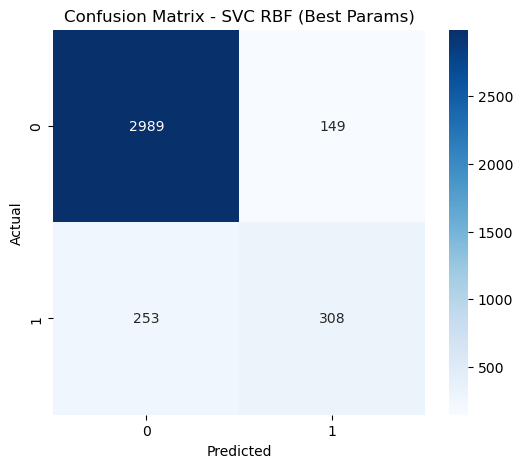

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      3138
           1       0.67      0.55      0.61       561

    accuracy                           0.89      3699
   macro avg       0.80      0.75      0.77      3699
weighted avg       0.88      0.89      0.89      3699



In [88]:
# 🔹 Modèle avec les meilleurs paramètres
svc_best_rbf = SVC(C=100, gamma=0.01, kernel='rbf')

# 🔹 Entraînement
svc_best_rbf.fit(X_train, y_train)

# 🔹 Prédiction (IMPORTANT: sur X_test)
SVC_RBF_pred = svc_best_rbf.predict(X_test)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_test, SVC_RBF_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - SVC RBF (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 Rapport de classification
print("Classification Report:\n")
print(classification_report(y_test, SVC_RBF_pred))

###  Modèle SVM avec noyau Poly

In [89]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Modèle de base
svc_poly = SVC()

# Grille de paramètres
param_grid_poly = {
    'C': [1, 10],
    'gamma': [0.1],
    'kernel': ['poly']
}

# Grid Search
grid_poly = GridSearchCV(
    estimator=svc_poly,
    param_grid=param_grid_poly,
    cv=3,
    scoring='recall'
)

# Entraînement
grid_poly.fit(X_train, y_train)
# Meilleurs paramètres
print(grid_poly.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'poly'}


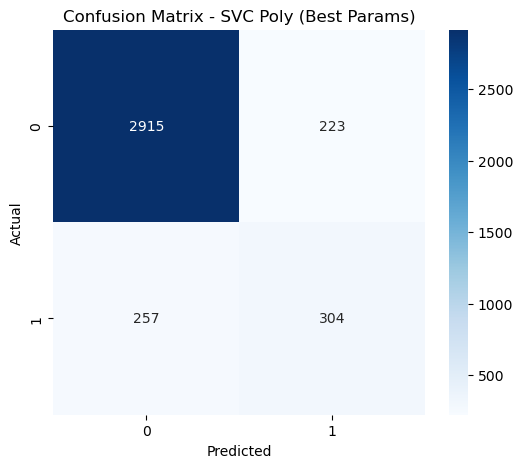

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      3138
           1       0.58      0.54      0.56       561

    accuracy                           0.87      3699
   macro avg       0.75      0.74      0.74      3699
weighted avg       0.87      0.87      0.87      3699



In [90]:
# 🔹 Modèle avec les meilleurs paramètres
svc_best = SVC(C=10, gamma=0.1, kernel='poly')

# 🔹 Entraînement
svc_best.fit(X_train, y_train)

# 🔹 Prédiction (IMPORTANT: sur X_test)
SVC_poly_pred = svc_best.predict(X_test)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_test, SVC_poly_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - SVC Poly (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 Rapport de classification
print("Classification Report:\n")
print(classification_report(y_test, SVC_poly_pred))

### decision tree 

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Modèle de base
tree = DecisionTreeClassifier(random_state=0)

# Grille d'hyperparamètres
tree_params = {
    'max_depth': range(1, 10),
    'max_features': range(3, X_train.shape[1]),
    'criterion': ['gini', 'entropy']
}

# GridSearchCV
tree_classifier = GridSearchCV(
    estimator=tree,
    param_grid=tree_params,
    cv=3,
    scoring='recall'
)

# Entraînement
tree_classifier.fit(X_train, y_train)

# Meilleurs résultats
print("Best params:", tree_classifier.best_params_)
print("Best score:", tree_classifier.best_score_)

Best params: {'criterion': 'entropy', 'max_depth': 1, 'max_features': 11}
Best score: 0.7988121752041574


### matrice de confusion et classification  de la decision tree

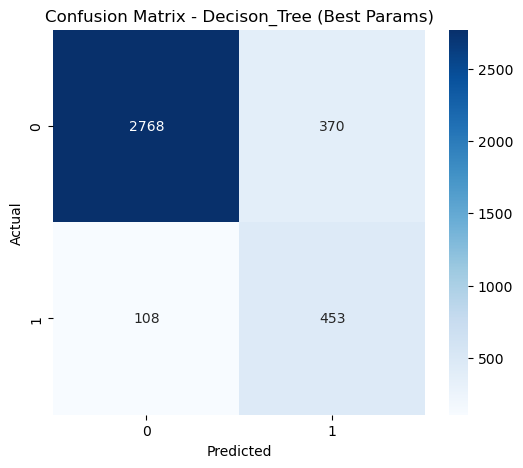

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3138
           1       0.55      0.81      0.65       561

    accuracy                           0.87      3699
   macro avg       0.76      0.84      0.79      3699
weighted avg       0.90      0.87      0.88      3699



In [92]:
# 🔹 Modèle avec les meilleurs paramètres
Decison_Tree_best = DecisionTreeClassifier(criterion='entropy', max_depth=1, max_features=11)

# 🔹 Entraînement
Decison_Tree_best.fit(X_train, y_train)

# 🔹 Prédiction (IMPORTANT: sur X_test)
DT_pred = Decison_Tree_best.predict(X_test)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_test, DT_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Decison_Tree (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 Rapport de classification
print("Classification Report:\n")
print(classification_report(y_test, DT_pred))

### Hyper-Parameter Tuning - Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use: \n')
pprint(rf.get_params())

Parameters currently in use: 

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


In [94]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Définir la grille d’hyperparamètres
random_grid = {
    'n_estimators': [int(x) for x in np.linspace(200, 2000, 10)],
    'max_features': ['sqrt', 'log2'],  # 'auto' est déprécié
    'max_depth': [int(x) for x in np.linspace(10, 110, 11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
# 2. Créer le modèle
rf = RandomForestClassifier()

# 3. Random Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=random_grid,
    n_iter=100,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Entraînement
rf_random.fit(X_train, y_train)

# 5. Résultats
print("Best parameters:", rf_random.best_params_)
print("Best score:", rf_random.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}
Best score: 0.9004755096111717


### matrice de confusion et classification  de la random forest

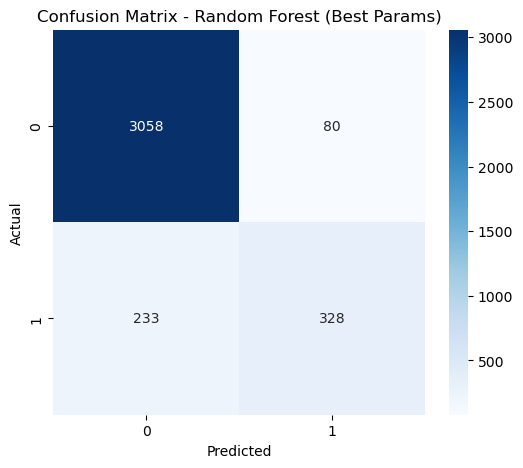

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3138
           1       0.80      0.58      0.68       561

    accuracy                           0.92      3699
   macro avg       0.87      0.78      0.81      3699
weighted avg       0.91      0.92      0.91      3699



In [95]:
# 🔹 Modèle avec les meilleurs paramètres
Random_forest_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=10,
    bootstrap=True,
)
# 🔹 Entraînement
Random_forest_best.fit(X_train, y_train)

# 🔹 Prédiction (IMPORTANT: sur X_test)
RF_pred = Random_forest_best.predict(X_test)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_test, RF_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔹 Rapport de classification
print("Classification Report:\n")
print(classification_report(y_test, RF_pred))

### Optimisation des performances via l%e Bagging decision tree

OOB Score (Bagging): 0.8943343760862009
Test Accuracy (Bagging): 0.9007839956745066


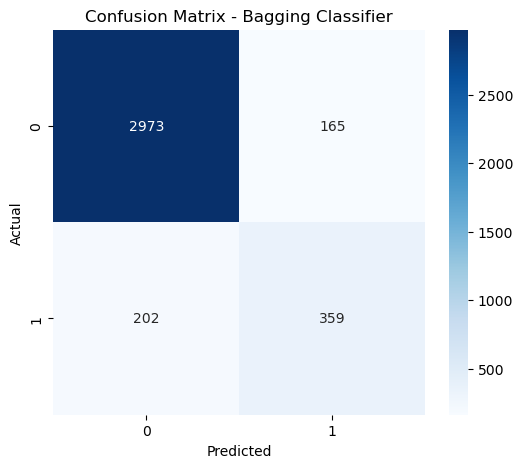

Classification Report (Bagging):

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      3138
           1       0.69      0.64      0.66       561

    accuracy                           0.90      3699
   macro avg       0.81      0.79      0.80      3699
weighted avg       0.90      0.90      0.90      3699



In [96]:
# ==============================
# Bagging Classifier (Extra Model)
# ==============================
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Bagging with DecisionTree base estimator
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True,
    random_state=42
)

# Train the model
bag_clf.fit(X_train, y_train)

# Out-of-bag score
print("OOB Score (Bagging):", bag_clf.oob_score_)

# Predictions
bag_pred = bag_clf.predict(X_test)

# Accuracy
print("Test Accuracy (Bagging):", accuracy_score(y_test, bag_pred))

# Confusion Matrix
cm_bag = confusion_matrix(y_test, bag_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_bag, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Bagging Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report (Bagging):\n")
print(classification_report(y_test, bag_pred))

### Comparaison de modèles avec ROC / AUC

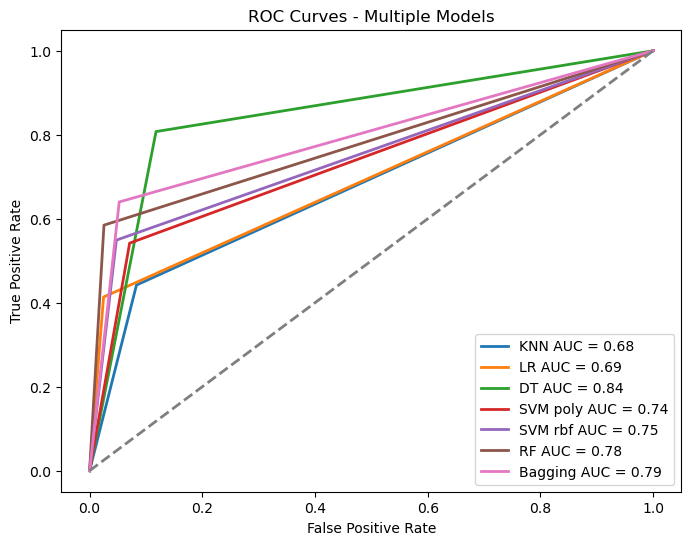

In [97]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics
import matplotlib.pyplot as plt

# Number of trees
n_estimators = [200, 100, 400, 50]

# ROC curves
fpr_knn, tpr_knn, _ = metrics.roc_curve(y_test,knn_pred)
fpr_lr, tpr_lr, _ = metrics.roc_curve(y_test, LR_pred)
fpr_dt, tpr_dt, _ = metrics.roc_curve(y_test,DT_pred)
fpr_svm_poly, tpr_svm_poly , _ = metrics.roc_curve(y_test,SVC_poly_pred)
fpr_svm_rbf, tpr_svm_rbf, _ = metrics.roc_curve(y_test, SVC_RBF_pred)
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test, RF_pred)
fpr_bag, tpr_bag, _ = metrics.roc_curve(y_test, bag_pred)

# AUC
auc_knn = metrics.auc(fpr_knn, tpr_knn)
auc_lr = metrics.auc(fpr_lr, tpr_lr)
auc_dt = metrics.auc(fpr_dt, tpr_dt)
auc_svmpoly = metrics.auc(fpr_svm_poly, tpr_svm_poly)
auc_svmrbf = metrics.auc(fpr_svm_rbf, tpr_svm_rbf)
auc_rf = metrics.auc(fpr_rf, tpr_rf)
auc_bag = metrics.auc(fpr_bag, tpr_bag)  

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, lw=2, label='KNN AUC = %.2f' % auc_knn)
plt.plot(fpr_lr, tpr_lr, lw=2, label='LR AUC = %.2f' % auc_lr)
plt.plot(fpr_dt, tpr_dt, lw=2, label='DT AUC = %.2f' % auc_dt)
plt.plot(fpr_svm_poly, tpr_svm_poly, lw=2, label='SVM poly AUC = %.2f' % auc_svmpoly)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, lw=2, label='SVM rbf AUC = %.2f' % auc_svmrbf)
plt.plot(fpr_rf, tpr_rf, lw=2, label='RF AUC = %.2f' % auc_rf)
plt.plot(fpr_bag, tpr_bag, lw=2, label='Bagging AUC = %.2f' % auc_bag)

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multiple Models')
plt.legend(loc='lower right')

plt.show()

### Inspect Feature Importance

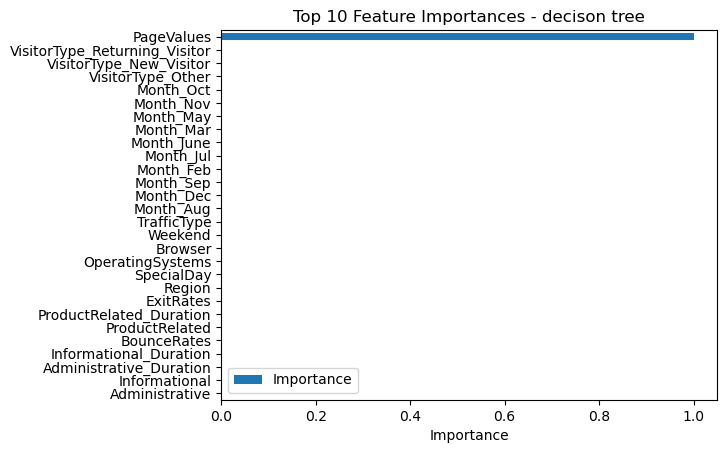

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 récupérer le meilleur modèle
best_dt = Decison_Tree_best

# 🔹 feature importances
dt_importances = pd.DataFrame(
    data=best_dt.feature_importances_,
    index=X_train.columns,
    columns=['Importance']
)

# 🔹 top 10
dt_importances = dt_importances.sort_values(by='Importance', ascending=False)

# 🔹 plot
dt_importances.sort_values(by='Importance').plot.barh()

plt.title('Top 10 Feature Importances - decison tree')
plt.xlabel('Importance')
plt.show()

### Evaluating with Cross Validation

In [101]:
# evaluate your models using k-fold cross-validation
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

# prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [102]:
#create function to train a model with cross validations and evaluate accuracy
def trainer_with_cv(model,X,y):
    '''Cross validation function. Expects a model,'''
    # evaluate model
    accuracy_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    print('Accuracy:')
    print(accuracy_scores)
    print(model.__class__.__name__,'Mean Accuracy: %.3f' % (mean(accuracy_scores)))
    
    precision_scores = cross_val_score(model, X, y, scoring='precision', cv=cv, n_jobs=-1)
    print('\nPrecision:')
    print(precision_scores)
    print(model.__class__.__name__,'Mean Precision: %.3f' % (mean(precision_scores)))
    
    recall_scores = cross_val_score(model, X, y, scoring='recall', cv=cv, n_jobs=-1)
    print('\nRecall:')
    print(recall_scores)
    print(model.__class__.__name__,'Mean Recall: %.3f' % (mean(recall_scores)))

In [103]:
trainer_with_cv(Decison_Tree_best,X,y)

Accuracy:
[0.8540146  0.86131387 0.83860503 0.88240065 0.88564477 0.85158151
 0.8702352  0.83617194 0.837794   0.83130576]
DecisionTreeClassifier Mean Accuracy: 0.855

Precision:
[0.         0.         0.         0.58888889 0.         0.
 0.53639847 0.56410256 0.58536585 0.        ]
DecisionTreeClassifier Mean Precision: 0.227

Recall:
[0.         0.         0.         0.8238342  0.         0.
 0.78212291 0.76237624 0.84       0.        ]
DecisionTreeClassifier Mean Recall: 0.321


### save the machine learning final model

In [104]:
import pickle
from sklearn.metrics import confusion_matrix
model = tree_classifier 
# Sauvegarder le modèle sur mon pc 
pickle.dump(model, open('online_shoppers_intention prdiction (DT)', 'wb'))
online_shoppers_intention_model = pickle.load(open('online_shoppers_intention prdiction (DT)', 'rb'))
#  Prédictions
y_pred = online_shoppers_intention_model.predict(X_test)
#  Matrice de confusion
print('Confusion matrix of best model:\n',
      confusion_matrix(y_test, y_pred))

Confusion matrix of best model:
 [[2768  370]
 [ 108  453]]


 ### Save All Preprocessing Objects 

In [109]:
import pickle

# Save the scaler (StandardScaler)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the OneHotEncoder (used for Month, VisitorType)
with open('onehot_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Save the feature columns (so we know how to order inputs)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

## create a data app with the use of streamlit 

In [69]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# -------------------------------
# Load saved objects
# -------------------------------
with open('online_shoppers_intention prdiction (DT)', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('onehot_encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

# -------------------------------
# Streamlit UI
# -------------------------------
st.set_page_config(page_title="Online Shoppers Intention", layout="centered")
st.title(" Will the visitor make a purchase?")
st.markdown("Enter the session details below.")

# Create two columns for better layout
col1, col2 = st.columns(2)

with col1:
    administrative = st.number_input("Administrative pages visited", min_value=0, step=1)
    administrative_duration = st.number_input("Time on administrative pages (seconds)", min_value=0.0, step=1.0)
    informational = st.number_input("Informational pages visited", min_value=0, step=1)
    informational_duration = st.number_input("Time on informational pages (seconds)", min_value=0.0, step=1.0)
    product_related = st.number_input("Product‑related pages visited", min_value=0, step=1)
    product_related_duration = st.number_input("Time on product pages (seconds)", min_value=0.0, step=1.0)
    bounce_rates = st.slider("Bounce Rates", 0.0, 0.2, 0.02, 0.01)
    exit_rates = st.slider("Exit Rates", 0.0, 0.2, 0.04, 0.01)
    page_values = st.number_input("Page Values", min_value=0.0, step=1.0)

with col2:
    special_day = st.slider("Special Day (closeness to a holiday)", 0.0, 1.0, 0.0, 0.05)
    operating_systems = st.selectbox("Operating System", options=list(range(1,9)), index=1)
    browser = st.selectbox("Browser", options=list(range(1,14)), index=1)
    region = st.selectbox("Region", options=list(range(1,10)), index=1)
    traffic_type = st.selectbox("Traffic Type", options=list(range(1,21)), index=1)
    weekend = st.selectbox("Weekend?", options=[0,1], format_func=lambda x: "Yes" if x==1 else "No")
    month = st.selectbox("Month", options=['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec'])
    visitor_type = st.selectbox("Visitor Type", options=['Returning_Visitor','New_Visitor','Other'])

# -------------------------------
# Build feature vector
# -------------------------------
# 1. Numerical features (same order as training)
num_features = ['Administrative', 'Administrative_Duration', 'Informational',
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']

input_data = {
    'Administrative': administrative,
    'Administrative_Duration': administrative_duration,
    'Informational': informational,
    'Informational_Duration': informational_duration,
    'ProductRelated': product_related,
    'ProductRelated_Duration': product_related_duration,
    'BounceRates': bounce_rates,
    'ExitRates': exit_rates,
    'PageValues': page_values,
    'SpecialDay': special_day,
    'OperatingSystems': operating_systems,
    'Browser': browser,
    'Region': region,
    'TrafficType': traffic_type,
    'Weekend': weekend
}

# 2. One‑hot encode month and visitor type
month_encoded = encoder.transform([[month, visitor_type]])
month_encoded_df = pd.DataFrame(month_encoded, columns=encoder.get_feature_names_out())

# 3. Combine all features
input_df = pd.DataFrame([input_data])
input_df = pd.concat([input_df, month_encoded_df], axis=1)

# 4. Reorder columns to match training order
for col in feature_columns:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[feature_columns]

# 5. Scale numerical columns (those that were scaled during training)
#    We need to know which columns were scaled – they are all numeric except the one‑hot columns.
#    The scaler was fit on the whole X_train (all columns). So we simply transform the whole row.
input_scaled = scaler.transform(input_df)

# -------------------------------
# Prediction
# -------------------------------
if st.button("Predict Purchase Intention"):
    pred = model.predict(input_scaled)[0]
    proba = model.predict_proba(input_scaled)[0][1]   # probability of class 1
    if pred == 1:
        st.success(f"✅ The visitor is likely to purchase! (Probability: {proba:.2f})")
    else:
        st.error(f"❌ The visitor is unlikely to purchase. (Probability: {proba:.2f})")

Overwriting app.py


In [38]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


## Local URL: http://localhost:8501
## Network URL: http://192.168.1.13:8501